# Question 1

## Sentiment analysis on the IMDB dataset

### Imports

In [30]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt

### Load Dataset

In [7]:
df = pd.read_csv("IMDB Dataset.csv")

In [8]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
df = df.iloc[:15000].copy()
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Text Preprocessing

In [13]:
def clean_text(text: str) -> str:
    # remove HTML breaks/tags
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    # keep letters + apostrophes (don't), replace others (numbers + other punctuations) with space
    text = re.sub(r"[^A-Za-z\s']", " ", text)

    # normalize whitespace + lowercase
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

X = df["review"].map(clean_text)
X

0        one of the other reviewers has mentioned that ...
1        a wonderful little production the filming tech...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's love in the time of money is a...
                               ...                        
14995    bobcat goldthwait should be commended for atte...
14996    and it's not because since her days on clariss...
14997    a traveling couple horton and hamilton stumble...
14998    this film is deeply disappointing not only tha...
14999    the revelation here is lana turner's dancing a...
Name: review, Length: 15000, dtype: object

In [15]:
# Convert labels to numeric: negative=0, positive=1
y = df["sentiment"].map({"negative": 0, "positive": 1})
y

0        1
1        1
2        1
3        0
4        1
        ..
14995    0
14996    1
14997    0
14998    0
14999    1
Name: sentiment, Length: 15000, dtype: int64

### Train-test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train size: 10500
Test size: 4500
Train positive rate: 0.49276190476190473
Test positive rate: 0.49266666666666664


### Build Model Pipeline

In [27]:
# CountVectorizer --> Linear SVM Classifier
model = Pipeline([
    ("vec", CountVectorizer(
        stop_words="english", # removes common English words like "the", "is"
        min_df=2, # ignore extremely rare tokens (appearing <2 docs)
        ngram_range=(1, 2) # unigrams + bigrams
    )),
    ("svm", LinearSVC(max_iter=5000))
])

### Train SVM

In [28]:
model.fit(X_train, y_train)

,steps,"[('vec', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


### Predict on test set

In [29]:
y_pred = model.predict(X_test)

### Model Performance

In [31]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.872
Precision: 0.8658047258136424
Recall   : 0.87595850248083
F1 Score : 0.8708520179372198


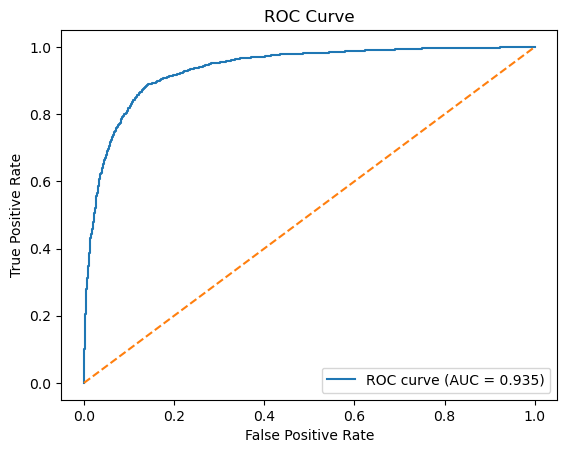

AUC: 0.9351291566719242


In [32]:
y_scores = model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.3f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

### Model Performance Explanation

The SVM classifier achieved an accuracy of 87.2%, indicating that the model correctly classified the majority of movie reviews. The precision (86.6%) shows that most reviews predicted as positive were indeed positive, while the recall (87.6%) indicates that the model successfully identified most of the actual positive reviews. The F1-score of 0.871 demonstrates a good balance between precision and recall. The ROC curve further confirms strong model performance, with an AUC of 0.935, indicating excellent separability between positive and negative reviews. Overall, the Linear SVM with CountVectorizer provides strong and balanced sentiment classification performance.

# Question 2

## Multi-class classification using SVM of wine dataset

### Imports

In [58]:
from sklearn.datasets import load_wine
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

### Load Wine dataset from scikit-learn

In [39]:
wine = load_wine()
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [42]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [44]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [47]:
X = wine.data
y = wine.target
target_names = wine.target_names

print("Dataset shape:", X.shape)
print("Classes:", np.unique(y), "->", target_names)

Dataset shape: (178, 13)
Classes: [0 1 2] -> ['class_0' 'class_1' 'class_2']


### Split dataset

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape[0])
print("Test size :", X_test.shape[0])



Train size: 106
Test size : 72


### Train multi-class SVM classifier

In [52]:
svm_clf = SVC(kernel="rbf", gamma="scale", C=1.0, random_state=42)
svm_clf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Predict

In [55]:
y_pred = svm_clf.predict(X_test)

### Performance

In [56]:
acc = accuracy_score(y_test, y_pred)

# For multi-class metrics, use averaging:
# - 'macro' = treat each class equally, then average
# - 'weighted' = weighted by number of samples in each class
prec_macro = precision_score(y_test, y_pred, average="macro")
rec_macro  = recall_score(y_test, y_pred, average="macro")
f1_macro   = f1_score(y_test, y_pred, average="macro")

prec_weighted = precision_score(y_test, y_pred, average="weighted")
rec_weighted  = recall_score(y_test, y_pred, average="weighted")
f1_weighted   = f1_score(y_test, y_pred, average="weighted")

print("\n=== Overall Performance ===")
print(f"Accuracy            : {acc:.4f}")

print("\n--- Macro Average (each class equally important) ---")
print(f"Precision (macro)   : {prec_macro:.4f}")
print(f"Recall (macro)      : {rec_macro:.4f}")
print(f"F1-score (macro)    : {f1_macro:.4f}")

print("\n--- Weighted Average (accounts for class counts) ---")
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted)   : {rec_weighted:.4f}")
print(f"F1-score (weighted) : {f1_weighted:.4f}")


=== Overall Performance ===
Accuracy            : 0.6806

--- Macro Average (each class equally important) ---
Precision (macro)   : 0.6359
Recall (macro)      : 0.6269
F1-score (macro)    : 0.6056

--- Weighted Average (accounts for class counts) ---
Precision (weighted): 0.6535
Recall (weighted)   : 0.6806
F1-score (weighted) : 0.6422


**Findings:**
The SVM classifier achieved an accuracy of 68.06%, indicating moderate performance on the Wine dataset. The macro F1-score (0.6056) is lower than the weighted F1-score (0.6422), suggesting that the model performs unevenly across the three classes and likely classifies some classes better than others. Overall, the results show reasonable predictive capability, but the model does not achieve strong class separation. The performance may be affected by differences in feature scales, as SVM is sensitive to feature magnitudes.

In [60]:
models = {
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", random_state=42))
    ]),
    
    "Polynomial SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="poly", degree=3, random_state=42))
    ]),
    
    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", random_state=42))
    ])
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
        "F1-score (macro)": f1_score(y_test, y_pred, average="macro")
    }

# Print results
for name, metrics in results.items():
    print(f"\n{name}")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")


Linear SVM
Accuracy: 0.9583
Precision (macro): 0.9625
Recall (macro): 0.9595
F1-score (macro): 0.9601

Polynomial SVM
Accuracy: 0.8889
Precision (macro): 0.9167
Recall (macro): 0.8840
F1-score (macro): 0.8944

RBF SVM
Accuracy: 0.9861
Precision (macro): 0.9889
Recall (macro): 0.9825
F1-score (macro): 0.9853


### Findings

The performance of the three SVM kernels shows that the RBF kernel performs best, achieving the highest accuracy (98.61%) and F1-score (98.53%), along with strong precision and recall values. The linear kernel also performs very well (95.83% accuracy), indicating that the Wine dataset is largely linearly separable. However, the RBF kernel slightly improves performance by capturing nonlinear relationships between features. The polynomial kernel performs the weakest (88.89% accuracy), suggesting that its nonlinear transformation does not model the data as effectively as RBF. Overall, the RBF SVM provides the most accurate and balanced classification performance.